<a href="https://colab.research.google.com/github/Aryanxx4/DL-Project/blob/main/RESNET50_NOFINETUNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Cell 1: Imports & Device Setup
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [23]:
# Cell 2 (NEW): Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
rgb_root = "/content/drive/MyDrive/EuroSAT"  # ← adjust this path

# Verify it looks correct
classes = sorted([d for d in os.listdir(rgb_root)
                  if os.path.isdir(os.path.join(rgb_root, d))])

print(f"Found {len(classes)} classes at: {rgb_root}\n")
for i, cls in enumerate(classes):
    n = len(os.listdir(os.path.join(rgb_root, cls)))
    print(f"  {i+1:>2}. {cls:<25} → {n} images")

Found 10 classes at: /content/drive/MyDrive/EuroSAT

   1. AnnualCrop                → 3000 images
   2. Forest                    → 3000 images
   3. HerbaceousVegetation      → 3000 images
   4. Highway                   → 2500 images
   5. Industrial                → 2500 images
   6. Pasture                   → 2000 images
   7. PermanentCrop             → 2500 images
   8. Residential               → 3000 images
   9. River                     → 2500 images
  10. SeaLake                   → 3000 images


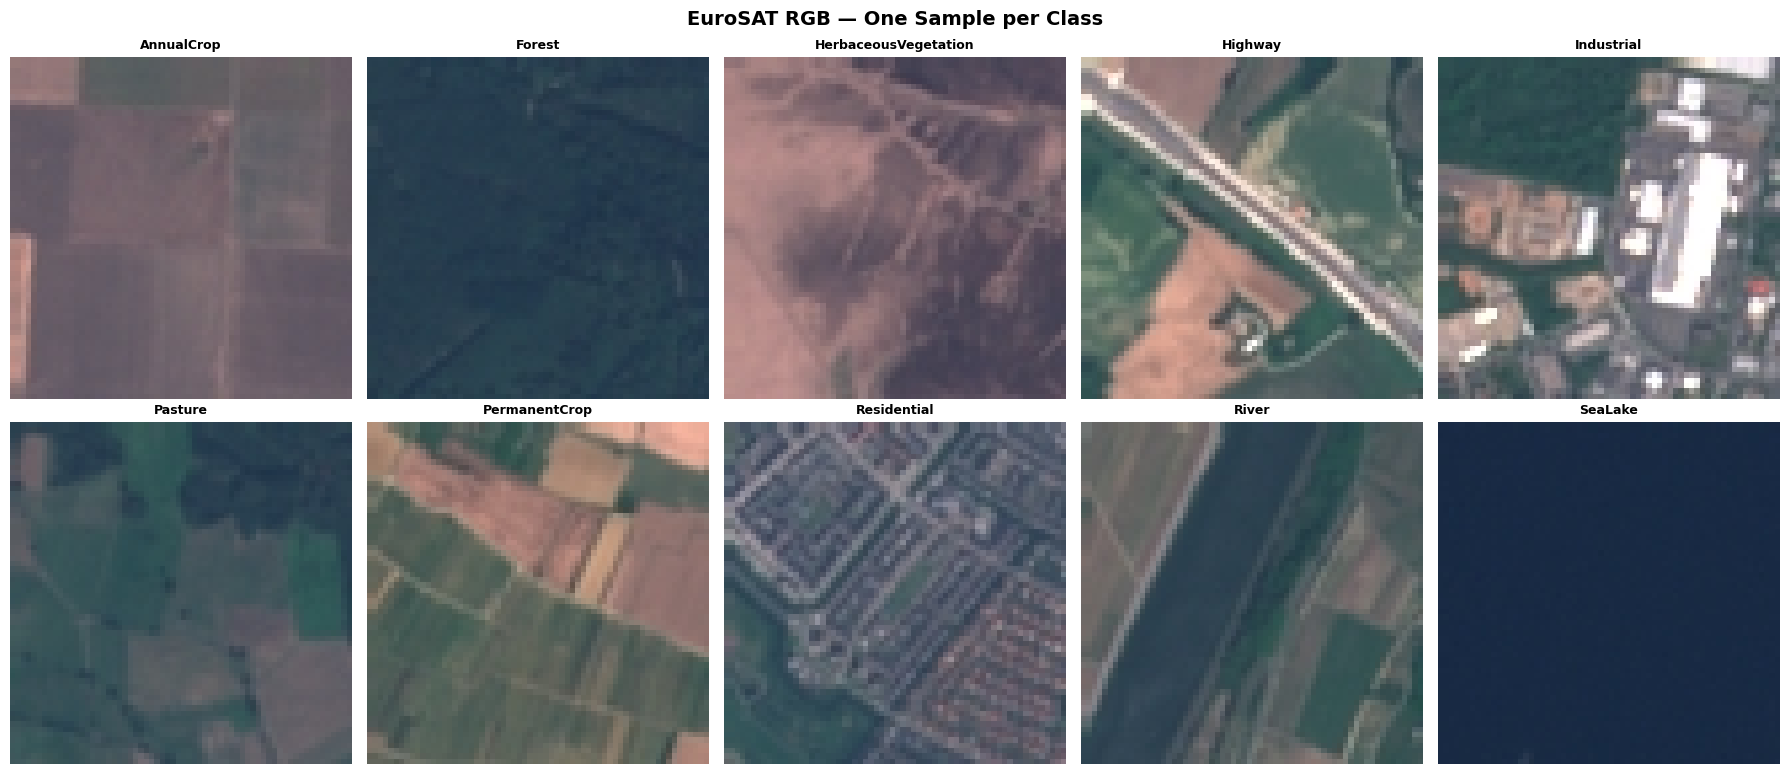

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(rgb_root, cls)
    img_file = sorted(os.listdir(cls_path))[0]
    img = Image.open(os.path.join(cls_path, img_file)).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("EuroSAT RGB — One Sample per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
BATCH_SIZE = 64
VAL_SPLIT  = 0.2   # 80/20 as used in the paper
SEED       = 42

# EuroSAT RGB mean & std (dataset-specific)
MEAN = [0.3444, 0.3803, 0.4078]
STD  = [0.2034, 0.1366, 0.1148]

cnn_train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

cnn_val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Build datasets
full_train_ds = datasets.ImageFolder(rgb_root, transform=cnn_train_transforms)
full_val_ds   = datasets.ImageFolder(rgb_root, transform=cnn_val_transforms)

total      = len(full_train_ds)
val_size   = int(total * VAL_SPLIT)
train_size = total - val_size

# Same split indices for both transforms
torch.manual_seed(SEED)
train_indices, val_indices = random_split(range(total), [train_size, val_size])

from torch.utils.data import Subset
train_ds_cnn = Subset(full_train_ds, train_indices.indices)
val_ds_cnn   = Subset(full_val_ds,   val_indices.indices)

train_loader_cnn = DataLoader(train_ds_cnn, batch_size=BATCH_SIZE,
                               shuffle=True,  num_workers=0, pin_memory=True)
val_loader_cnn   = DataLoader(val_ds_cnn,   batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0, pin_memory=True)

print(f"Total images : {total:,}")
print(f"Train images : {train_size:,}")
print(f"Val images   : {val_size:,}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Classes      : {full_train_ds.classes}")

Total images : 27,000
Train images : 21,600
Val images   : 5,400
Batch size   : 64
Classes      : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [27]:
class TwoLayerCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(TwoLayerCNN, self).__init__()

        # Conv Block 1: 3 → 32 filters
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 64x64 → 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                           # 64x64 → 32x32
        )

        # Conv Block 2: 32 → 64 filters
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32x32 → 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                           # 32x32 → 16x16
        )

        # Fully Connected Head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model_cnn = TwoLayerCNN(num_classes=10).to(device)
print(model_cnn)

trainable_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {trainable_params:,}")

TwoLayerCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total trainable parameters: 4,216,714


In [28]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'],   label='Val')
    ax2.set_title(f'{title} — Accuracy (%)')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend(); ax2.grid(True)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [29]:
NUM_EPOCHS  = 30
criterion   = nn.CrossEntropyLoss()
optimizer   = optim.Adam(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

history_cnn  = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_cnn = 0.0

print(f"Training Two-Layer CNN for {NUM_EPOCHS} epochs...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>9} | {'Val Acc':>8}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model_cnn, train_loader_cnn, criterion, optimizer)
    vl_loss, vl_acc = evaluate(model_cnn, val_loader_cnn, criterion)
    scheduler.step()

    history_cnn['train_loss'].append(tr_loss)
    history_cnn['val_loss'].append(vl_loss)
    history_cnn['train_acc'].append(tr_acc)
    history_cnn['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc_cnn:
        best_val_acc_cnn = vl_acc
        torch.save(model_cnn.state_dict(), "best_twolayer_cnn.pth")
        flag = " ← best"
    else:
        flag = ""

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | "
          f"{vl_loss:>9.4f} | {vl_acc:>7.2f}%{flag}")

print(f"\n Best Val Accuracy (Two-Layer CNN): {best_val_acc_cnn:.2f}%")

Training Two-Layer CNN for 30 epochs...

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     1.6084 |    43.23% |    1.0201 |   63.43% ← best
     2 |     1.2136 |    55.50% |    0.7961 |   71.20% ← best
     3 |     1.0989 |    59.80% |    0.6964 |   73.98% ← best
     4 |     1.0281 |    62.25% |    0.6824 |   76.63% ← best
     5 |     0.9791 |    64.18% |    0.6771 |   76.13%
     6 |     0.9263 |    66.85% |    0.6548 |   75.20%
     7 |     0.8847 |    68.03% |    0.5538 |   79.74% ← best
     8 |     0.8533 |    69.46% |    0.6562 |   76.13%
     9 |     0.8343 |    70.00% |    0.5286 |   81.72% ← best
    10 |     0.8162 |    71.11% |    0.5272 |   80.22%
    11 |     0.7250 |    74.73% |    0.4688 |   83.52% ← best
    12 |     0.6925 |    76.03% |    0.4433 |   85.07% ← best
    13 |     0.6860 |    76.11% |    0.4620 |   84.69%
    14 |     0.6805 |    76.29% |    0.4187 |   86.24% ← best
    15 |    

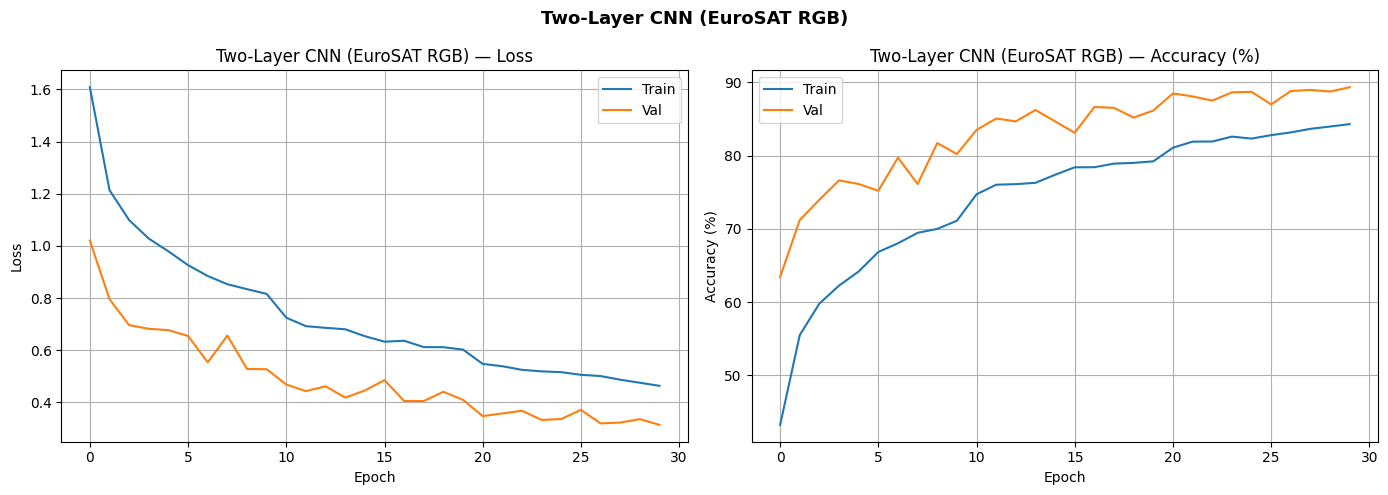

In [30]:
plot_history(history_cnn, "Two-Layer CNN (EuroSAT RGB)")

In [31]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

resnet_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

resnet_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Reuse the SAME indices from the 80/20 split above
full_train_ds_r = datasets.ImageFolder(rgb_root, transform=resnet_train_transforms)
full_val_ds_r   = datasets.ImageFolder(rgb_root, transform=resnet_val_transforms)

train_ds_r = Subset(full_train_ds_r, train_indices.indices)
val_ds_r   = Subset(full_val_ds_r,   val_indices.indices)

train_loader_r = DataLoader(train_ds_r, batch_size=64, shuffle=True,
                             num_workers=2, pin_memory=True)
val_loader_r   = DataLoader(val_ds_r,   batch_size=64, shuffle=False,
                             num_workers=2, pin_memory=True)

print(f"ResNet DataLoaders ready — image size: 224×224")
print(f"Train: {len(train_ds_r):,}  |  Val: {len(val_ds_r):,}")

ResNet DataLoaders ready — image size: 224×224
Train: 21,600  |  Val: 5,400


In [32]:
from torchvision.models import resnet50, ResNet50_Weights

model_resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# ── Step 1: Freeze ALL layers ──────────────────────────────────
for param in model_resnet.parameters():
    param.requires_grad = False

# ── Step 2: Replace final FC with 10-class head ────────────────
# This new layer has requires_grad=True by default
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)

model_resnet = model_resnet.to(device)

# Verify freeze
trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model_resnet.parameters() if not p.requires_grad)

print("ResNet-50 loaded with ImageNet weights")
print(f"  🔒 Frozen params (ImageNet backbone) : {frozen:,}")
print(f"  🔓 Trainable params (new head only)  : {trainable:,}")
print(f"\nOnly the final FC layer will be trained — backbone is untouched.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 117MB/s]


ResNet-50 loaded with ImageNet weights
  🔒 Frozen params (ImageNet backbone) : 23,508,032
  🔓 Trainable params (new head only)  : 20,490

Only the final FC layer will be trained — backbone is untouched.


In [33]:
NUM_EPOCHS_R   = 20
# Only pass the new head's parameters to the optimizer
optimizer_r    = optim.Adam(model_resnet.fc.parameters(), lr=1e-3)
scheduler_r    = optim.lr_scheduler.StepLR(optimizer_r, step_size=7, gamma=0.5)

history_resnet   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_r   = 0.0

print(f"Training ResNet-50 head for {NUM_EPOCHS_R} epochs...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>9} | {'Val Acc':>8}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS_R + 1):
    tr_loss, tr_acc = train_one_epoch(model_resnet, train_loader_r, criterion, optimizer_r)
    vl_loss, vl_acc = evaluate(model_resnet, val_loader_r, criterion)
    scheduler_r.step()

    history_resnet['train_loss'].append(tr_loss)
    history_resnet['val_loss'].append(vl_loss)
    history_resnet['train_acc'].append(tr_acc)
    history_resnet['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc_r:
        best_val_acc_r = vl_acc
        torch.save(model_resnet.state_dict(), "best_resnet_pretrained.pth")
        flag = " ← best"
    else:
        flag = ""

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | "
          f"{vl_loss:>9.4f} | {vl_acc:>7.2f}%{flag}")

print(f"\n Best Val Accuracy (ResNet-50, No Fine-Tune): {best_val_acc_r:.2f}%")

Training ResNet-50 head for 20 epochs...

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     0.4906 |    85.84% |    0.2632 |   91.52% ← best
     2 |     0.2694 |    91.29% |    0.2317 |   91.96% ← best
     3 |     0.2367 |    92.05% |    0.2015 |   93.35% ← best
     4 |     0.2190 |    92.48% |    0.1867 |   93.78% ← best
     5 |     0.2068 |    92.95% |    0.1799 |   94.11% ← best
     6 |     0.1960 |    93.28% |    0.1707 |   94.31% ← best
     7 |     0.1975 |    93.28% |    0.1818 |   93.67%
     8 |     0.1704 |    94.13% |    0.1669 |   94.02%
     9 |     0.1689 |    94.12% |    0.1645 |   94.17%
    10 |     0.1650 |    94.31% |    0.1616 |   94.35% ← best
    11 |     0.1663 |    94.33% |    0.1543 |   94.43% ← best
    12 |     0.1623 |    94.42% |    0.1628 |   94.44% ← best
    13 |     0.1650 |    94.32% |    0.1605 |   94.30%
    14 |     0.1551 |    94.60% |    0.1522 |   94.91% ← best
    

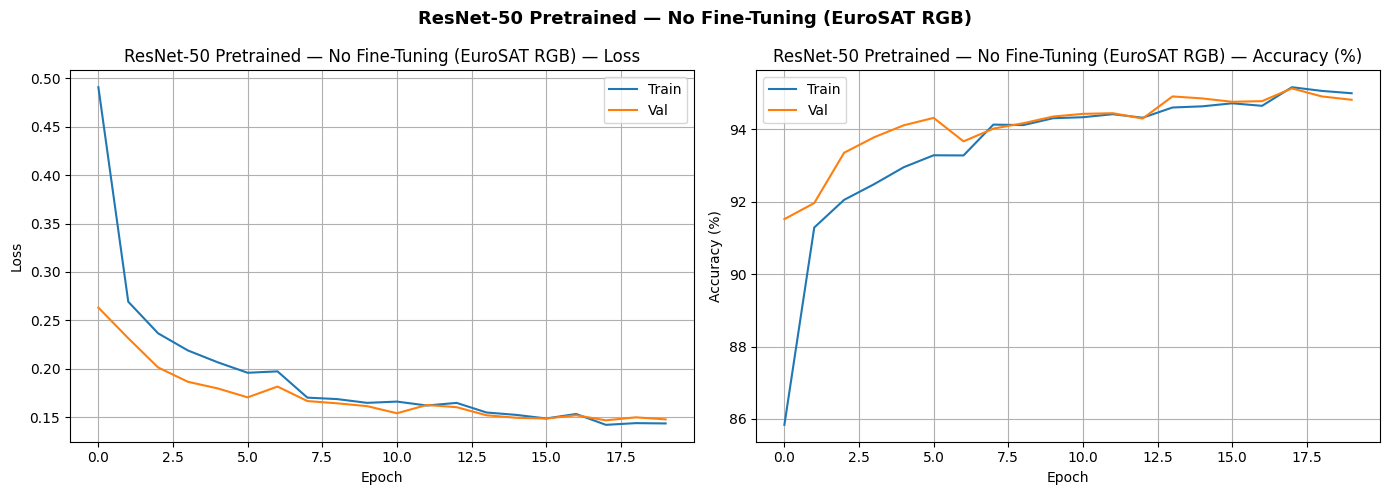

In [34]:
plot_history(history_resnet, "ResNet-50 Pretrained — No Fine-Tuning (EuroSAT RGB)")

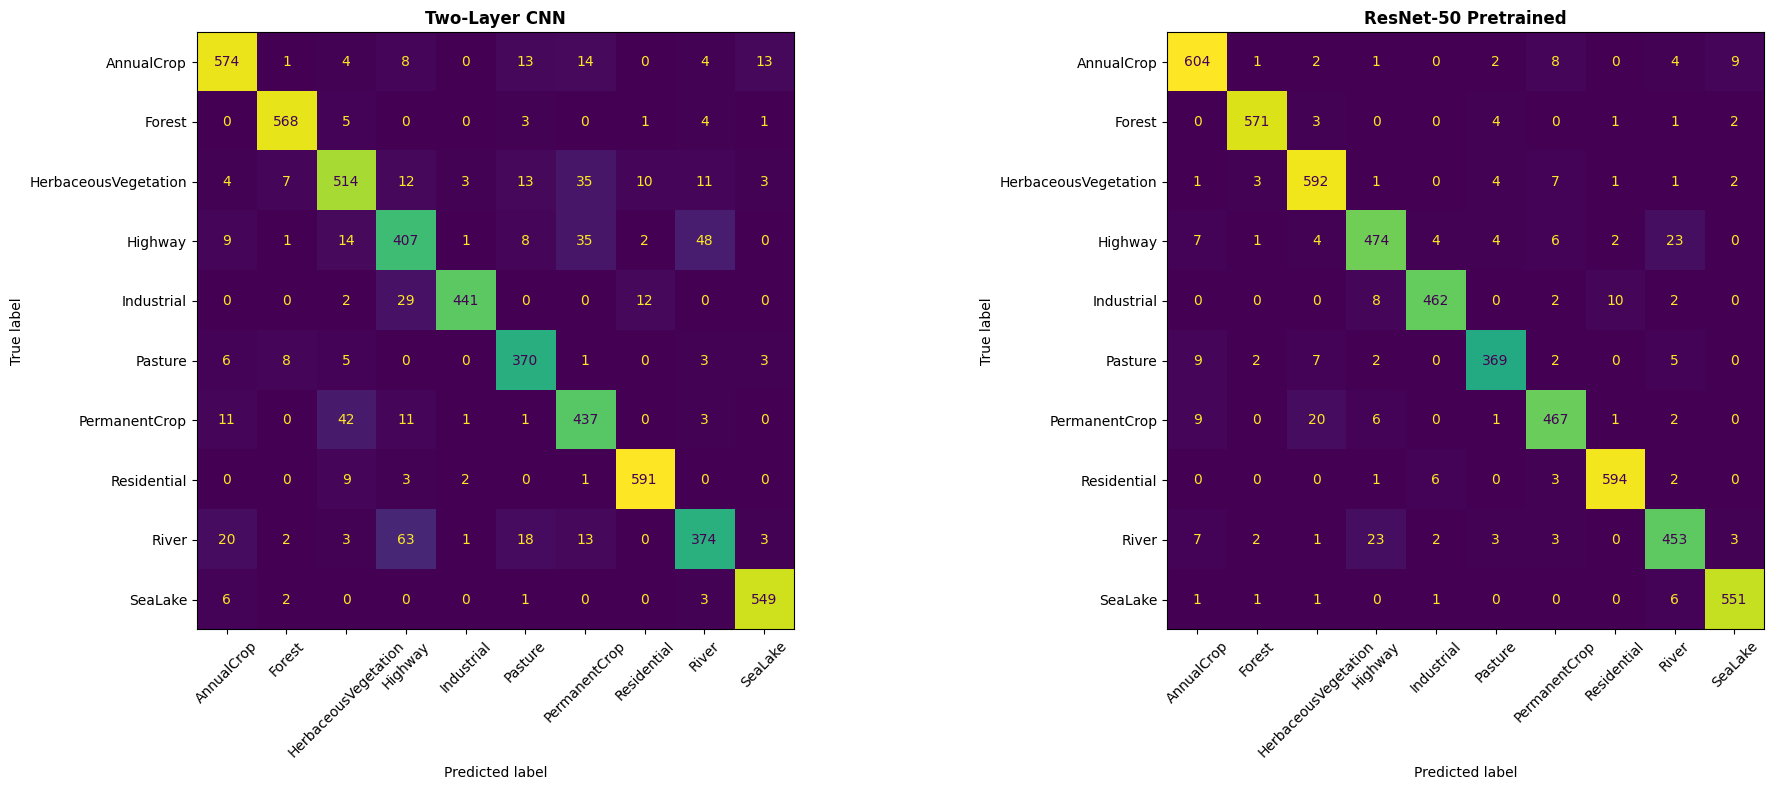

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_all_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds  = model(images).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

class_names = full_train_ds.classes

# Load best saved weights before evaluating
model_cnn.load_state_dict(torch.load("best_twolayer_cnn.pth"))
model_resnet.load_state_dict(torch.load("best_resnet_pretrained.pth"))

# Get predictions
true_cnn, pred_cnn    = get_all_preds(model_cnn,    val_loader_cnn)
true_r,   pred_r      = get_all_preds(model_resnet,  val_loader_r)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, true, pred, title in zip(
        axes,
        [true_cnn,      true_r],
        [pred_cnn,      pred_r],
        ["Two-Layer CNN", "ResNet-50 Pretrained"]):

    cm   = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
print("\n" + "="*62)
print(f"  {'Model':<38} | {'Best Val Acc':>10}")
print("="*62)
print(f"  {'Two-Layer CNN (trained from scratch)':<38} | {best_val_acc_cnn:>9.2f}%")
print(f"  {'ResNet-50 (ImageNet frozen, head only)':<38} | {best_val_acc_r:>9.2f}%")
print("="*62)
print("\n  Paper benchmark values (RGB, 80/20 split):")
print(f"  {'Two-Layer CNN':<38} : ~87.96%")
print(f"  {'ResNet-50 (fine-tuned)':<38} : ~96.43%")
print("\n  Note: Paper's ResNet used full fine-tuning.")
print("  Your ResNet uses frozen backbone — expect slightly lower accuracy.")


  Model                                  | Best Val Acc
  Two-Layer CNN (trained from scratch)   |     89.35%
  ResNet-50 (ImageNet frozen, head only) |     95.13%

  Paper benchmark values (RGB, 80/20 split):
  Two-Layer CNN                          : ~87.96%
  ResNet-50 (fine-tuned)                 : ~96.43%

  Note: Paper's ResNet used full fine-tuning.
  Your ResNet uses frozen backbone — expect slightly lower accuracy.
